In [1]:
# TASK 1 - Credit Scoring Model
# TASK 3 - Handwritten Character Recognition
# TASK 4 - Disease Prediction from Medical Data

# <h><center><b>**CodeAlpha Internship Program**</b></center></h>
### <h><center><b>**TASK 4 - Disease Prediction from Medical Data**</b></center></h>

**GitHub Repository-** **https://github.com/anweshabose/Disease_Prediction_Model**

# **ANTICIPATING DISEASES FROM MEDICAL DATA**

![](https://www.cell.com/cms/10.1016/j.heliyon.2024.e38731/asset/8c3881e4-b8de-454a-875a-14cf7f470f87/main.assets/gr1_lrg.jpg)

### **Take care of your Health because Blessings are not valued till they are gone.**

# **Introduction**

Anticipating diseases from patient data is a crucial application of machine learning in healthcare. By analyzing historical medical records, lifestyle factors, and clinical test results, predictive models can identify patterns that indicate potential health risks. These models assist in early diagnosis.

Machine learning techniques, such as decision trees, logistic regression, KNN, and random forest, play a vital role in processing vast amounts of patient data efficiently. Feature engineering, dataset preprocessing, and encoding methods enhance the accuracy of disease prediction models.

In this project we have trained the model with 6 different Algorithms and the best algorithm is used to predict the presence of Disease on the basis of Symptoms, Medical reports that you will provide. So, there is 80% chance that it will provide the accurate result. We will take a look at real world data and use machine learning techniques to build the model that can Predict the Disease.

# **Project Outline**

**Steps that we follow:**

- Installing and importing all the required libraries.
- Importing the csv file.
- Data Description.
- Data Processing
- i) Data Processing - Finding and filling Missing Values
- ii) Data Processing - Ordinal Encoding
- iii) Data Processing - One Hot Encoding
- Feature Scaling
- Prepare the Dataset for ML Training
- Model 1: Logistic Regression
- Model 2: KNN
- Model 3: SVM
- Model 4: Naive Bayes
- Model 5: Decision Tree Classifier
- Model 6: Random Forest
- Performance Evaluation
- Prediction with New Data
- Summary

# Installing and importing all the required libraries

In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [69]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder

In [70]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn import svm
from sklearn.naive_bayes import GaussianNB

In [71]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score 
from sklearn.metrics import precision_score
from sklearn.metrics import f1_score
from sklearn.metrics import recall_score

# Importing the CSV file

In [72]:
df = pd.read_csv("Disease_symptom_and_patient_profile_dataset.csv")
df.head(5)

,Disease,Fever,Cough,Fatigue,Difficulty Breathing,Age,Gender,Blood Pressure,Cholesterol Level,Outcome Variable
0,Influenza,Yes,No,Yes,Yes,19,Female,Low,Normal,Positive
1,Common Cold,No,Yes,Yes,No,25,Female,Normal,Normal,Negative
2,Eczema,No,Yes,Yes,No,25,Female,Normal,Normal,Negative
3,Asthma,Yes,Yes,No,Yes,25,Male,Normal,Normal,Positive
4,Asthma,Yes,Yes,No,Yes,25,Male,Normal,Normal,Positive


# Data Description

In [73]:
df.shape

(349, 10)

In [74]:
df.describe()

,Age
count,349.000000
mean,46.323782
std,13.085090
min,19.000000
25%,35.000000
50%,45.000000
75%,55.000000
max,90.000000


In [75]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349 entries, 0 to 348
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Disease               349 non-null    object
 1   Fever                 349 non-null    object
 2   Cough                 349 non-null    object
 3   Fatigue               349 non-null    object
 4   Difficulty Breathing  349 non-null    object
 5   Age                   349 non-null    int64 
 6   Gender                349 non-null    object
 7   Blood Pressure        349 non-null    object
 8   Cholesterol Level     349 non-null    object
 9   Outcome Variable      349 non-null    object
dtypes: int64(1), object(9)
memory usage: 27.4+ KB


# Data Processing

# i) Data Processing - Finding and filling Missing Values

In [76]:
df.isnull().sum()

Disease                 0
Fever                   0
Cough                   0
Fatigue                 0
Difficulty Breathing    0
Age                     0
Gender                  0
Blood Pressure          0
Cholesterol Level       0
Outcome Variable        0
dtype: int64

### Thus, all there are no Missing values.

# ii) Data Processing - Ordinal Encoding
**We are using ordinal encoding only when we need to label the categorical values inside the column**

In [77]:
df["Outcome Variable"].unique()

array(['Positive', 'Negative'], dtype=object)

In [78]:
# In target column, we are basically targeting the presence of disease.
# So, "Positive" in Outcome column should be given more prority than "Negetive".

ord_encoder1 = OrdinalEncoder(categories = [['Negative', 'Positive']])
df["Outcome Variable"] = ord_encoder1.fit_transform(df[["Outcome Variable"]])
df.head(2)

,Disease,Fever,Cough,Fatigue,Difficulty Breathing,Age,Gender,Blood Pressure,Cholesterol Level,Outcome Variable
0,Influenza,Yes,No,Yes,Yes,19,Female,Low,Normal,1.0
1,Common Cold,No,Yes,Yes,No,25,Female,Normal,Normal,0.0


In [79]:
df["Fever"].unique()

array(['Yes', 'No'], dtype=object)

In [80]:
# There is more possibility of having disease when someone have fever. 
# So, "Yes" in Fever column should be given more prority than "No".

ord_encoder2 = OrdinalEncoder(categories = [['No', 'Yes']])
df["Fever"] = ord_encoder2.fit_transform(df[["Fever"]])
df.head(2)

,Disease,Fever,Cough,Fatigue,Difficulty Breathing,Age,Gender,Blood Pressure,Cholesterol Level,Outcome Variable
0,Influenza,1.0,No,Yes,Yes,19,Female,Low,Normal,1.0
1,Common Cold,0.0,Yes,Yes,No,25,Female,Normal,Normal,0.0


In [81]:
df["Cough"].unique()

array(['No', 'Yes'], dtype=object)

In [82]:
# There is more possibility of having disease when someone have cough & cold. 
# So, "Yes" in Cough column should be given more prority than "No".

ord_encoder3 = OrdinalEncoder(categories = [['No', 'Yes']])
df["Cough"] = ord_encoder3.fit_transform(df[["Cough"]])
df.head(2)

,Disease,Fever,Cough,Fatigue,Difficulty Breathing,Age,Gender,Blood Pressure,Cholesterol Level,Outcome Variable
0,Influenza,1.0,0.0,Yes,Yes,19,Female,Low,Normal,1.0
1,Common Cold,0.0,1.0,Yes,No,25,Female,Normal,Normal,0.0


In [83]:
df["Difficulty Breathing"].unique()

array(['Yes', 'No'], dtype=object)

In [84]:
# There is more possibility of having disease when someone face Difficulty while Breathing. 
# So, "Yes" in Difficulty Breathing column should be given more prority than "No".

ord_encoder4 = OrdinalEncoder(categories = [['No', 'Yes']])
df["Difficulty Breathing"] = ord_encoder4.fit_transform(df[["Difficulty Breathing"]])
df.head(2)

,Disease,Fever,Cough,Fatigue,Difficulty Breathing,Age,Gender,Blood Pressure,Cholesterol Level,Outcome Variable
0,Influenza,1.0,0.0,Yes,1.0,19,Female,Low,Normal,1.0
1,Common Cold,0.0,1.0,Yes,0.0,25,Female,Normal,Normal,0.0


In [85]:
df["Blood Pressure"].unique()

array(['Low', 'Normal', 'High'], dtype=object)

In [86]:
# There is more possibility of having disease when someone have both "High" and "Low" bp.
# So, both "High" and "Low" in Blood Pressure column should be given more prority than "Normal".

# df["Blood Pressure"] = [1 if i == "Low" or i == "High" else 0 for i in df["Blood Pressure"]]
df["Blood Pressure"] = [0 if i == "Normal" else 1 for i in df["Blood Pressure"]]
df.head(2)

,Disease,Fever,Cough,Fatigue,Difficulty Breathing,Age,Gender,Blood Pressure,Cholesterol Level,Outcome Variable
0,Influenza,1.0,0.0,Yes,1.0,19,Female,1,Normal,1.0
1,Common Cold,0.0,1.0,Yes,0.0,25,Female,0,Normal,0.0


In [87]:
df["Cholesterol Level"].unique()

array(['Normal', 'Low', 'High'], dtype=object)

In [88]:
# There is more possibility of having disease when someone have high chol level. 
# So, "High" in Cholestrol level column should be given more prority than "Low".

ord_encoder5 = OrdinalEncoder(categories = [['Normal', 'Low', 'High']])
df["Cholesterol Level"] = ord_encoder5.fit_transform(df[["Cholesterol Level"]])
df.head(2)

,Disease,Fever,Cough,Fatigue,Difficulty Breathing,Age,Gender,Blood Pressure,Cholesterol Level,Outcome Variable
0,Influenza,1.0,0.0,Yes,1.0,19,Female,1,0.0,1.0
1,Common Cold,0.0,1.0,Yes,0.0,25,Female,0,0.0,0.0


In [89]:
df["Fatigue"].unique()

array(['Yes', 'No'], dtype=object)

In [90]:
# There is more possibility of having disease when someone feels Tired always for no reason. 
# So, "Yes" in Fatigue column should be given more prority than "No".

ord_encoder6 = OrdinalEncoder(categories = [['No', 'Yes']])
df["Fatigue"] = ord_encoder6.fit_transform(df[["Fatigue"]])
df.head(2)

,Disease,Fever,Cough,Fatigue,Difficulty Breathing,Age,Gender,Blood Pressure,Cholesterol Level,Outcome Variable
0,Influenza,1.0,0.0,1.0,1.0,19,Female,1,0.0,1.0
1,Common Cold,0.0,1.0,1.0,0.0,25,Female,0,0.0,0.0


# iii) Data Processing - One Hot Encoding
**We are using One Hot encoding only when we don't need to label the categorical values inside the column**

In [91]:
# We cannot label the disease column bcz "Allergy" is also a disease and "Heart Attack" is also a disease.
# One Hot Encoding is not applied bcz there are many unique elements inside the "Disease" column.
# If One hot encoding is performed, then it will make the dataset bulky.

df["Disease"] = [1 for i in df["Disease"]]

In [92]:
# We cannot assume that Male is more sick than female or vice-versa. It depends on their immunity power.
# So, cannot label the elements in "Gender" column. So, its better to perform One hot encoding.

ohe_encoder7 = OneHotEncoder()
encoded7_array = ohe_encoder7.fit_transform(df[["Gender"]]).toarray()
encoder_df7 = pd.DataFrame(encoded7_array, columns = ohe_encoder7.get_feature_names_out())
df = pd.concat([df, encoder_df7], axis = 1)
df.drop('Gender', axis=1, inplace=True)
df.head(2)

,Disease,Fever,Cough,Fatigue,Difficulty Breathing,Age,Blood Pressure,Cholesterol Level,Outcome Variable,Gender_Female,Gender_Male
0,1,1.0,0.0,1.0,1.0,19,1,0.0,1.0,1.0,0.0
1,1,0.0,1.0,1.0,0.0,25,0,0.0,0.0,1.0,0.0


### Thus, all Categorical values are converted to Numerical values

# Feature Scaling
Feature Scaling is a technique used in machine learning to normalize or standardize numerical data so that features are on a similar scale.

In [93]:
# Standardizes the features by subtracting the mean and dividing by the standard deviation
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df.drop('Outcome Variable', axis=1))  
# Target variable should be excluded from scaling

# Prepare the Dataset for ML Training

In [94]:
X = pd.DataFrame(scaled_features, columns=df.drop(columns=["Outcome Variable"]).columns)  # X: Independent variable
y = df["Outcome Variable"]   # y: Dependent variable

In [95]:
# Split the Dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [96]:
df.shape

(349, 11)

In [97]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(279, 10)
(70, 10)
(279,)
(70,)


# **Model 1: Logistic Regression**

In [98]:
# Model Training: Here, we are training the model with X_train and y_train
log_model = LogisticRegression()
log_model.fit(X_train, y_train)

LogisticRegression()

In [99]:
# Predicting the trained-model on X_test to get the predicted values of y.
logistic_y_preds = log_model.predict(X_test)

In [100]:
# Logistic accuracy score: checking whether predicted values of y is equal to Actual values of y.
log_accuracy = accuracy_score(y_test, logistic_y_preds)
print(f"Logistic Regression Accuracy: {log_accuracy:.2f}")

Logistic Regression Accuracy: 0.56


# **Model 2: Support Vector Machine (SVM)**

In [101]:
# Model Training: Here, we are training the model with X_train and y_train
svm_model = svm.SVC()
svm_model.fit(X_train,y_train)

SVC()

In [102]:
# Predicting the trained-model on X_test to get the predicted values of y.
svm_y_preds = svm_model.predict(X_test)

In [103]:
# SVM accuracy score: checking whether predicted values of y is equal to Actual values of y.
svm_accuracy = accuracy_score(y_test, svm_y_preds)
print(f"SVM Accuracy: {svm_accuracy:.2f}")

SVM Accuracy: 0.66


# **Model 3: Naive Bayes**

In [104]:
# Model Training: Here, we are training the model with X_train and y_train
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

GaussianNB()

In [105]:
# Predicting the trained-model on X_test to get the predicted values of y.
nb_y_preds = nb_model.predict(X_test)

In [106]:
# Naive Bayes accuracy score: checking whether predicted values of y is equal to Actual values of y.
nb_accuracy = accuracy_score(nb_y_preds, y_test)
print(f"Naive Bayes Accuracy: {nb_accuracy:.2f}")

Naive Bayes Accuracy: 0.53


# **Model 4: KNN Classifier**

In [107]:
# Model Training: Here, we are training the model with X_train and y_train
KNN_model = KNeighborsClassifier(algorithm='auto',leaf_size=30,metric='minkowski',n_neighbors=11,weights='uniform')
KNN_model.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=11)

In [108]:
# Predicting the trained-model on X_test to get the predicted values of y.
KNN_y_preds=KNN_model.predict(X_test)

In [109]:
# KNN accuracy score: checking whether predicted values of y is equal to Actual values of y.
KNN_accuracy = accuracy_score(y_test, KNN_y_preds)
print(f"KNN Accuracy: {KNN_accuracy:.2f}")

KNN Accuracy: 0.67


# **Model 5: Decision Tree Classifier**

In [110]:
# Model Training: Here, we are training the model with X_train and y_train
Decision_Tree_model = DecisionTreeClassifier(random_state=42)
Decision_Tree_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [111]:
# Predicting the trained-model on X_test to get the predicted values of y.
Decision_Tree_y_preds = Decision_Tree_model.predict(X_test)

In [112]:
# Decision_Tree accuracy score: checking whether predicted values of y is equal to Actual values of y.
Decision_Tree_accuracy = accuracy_score(y_test, Decision_Tree_y_preds)
print(f"Decision_Tree Accuracy: {Decision_Tree_accuracy:.2f}")

Decision_Tree Accuracy: 0.74


# **Model 6: Random Forest Classifier**

In [113]:
# Model Training: Here, we are training the model with X_train and y_train
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [114]:
# Predicting the trained-model on X_test to get the predicted values of y.
rf_y_preds = rf_model.predict(X_test)

In [115]:
# Random Forest accuracy score: checking whether predicted values of y is equal to Actual values of y.
rf_accuracy = accuracy_score(y_test, rf_y_preds)
print(f"Random Forest Accuracy: {rf_accuracy:.2f}")

Random Forest Accuracy: 0.80


# Model Performance using Performance Metrics

In [116]:
accuracy_list = []
precision_list = []
f1_score_list = []
recall_list = []

In [117]:
# Logistic Regression

accuracy_list.append(accuracy_score(y_test, logistic_y_preds))
precision_list.append(precision_score(y_test, logistic_y_preds, average='weighted'))
recall_list.append(recall_score(y_test, logistic_y_preds, average='weighted'))
f1_score_list.append(f1_score(y_test, logistic_y_preds, average='weighted'))

In [118]:
# SVM

accuracy_list.append(accuracy_score(y_test, svm_y_preds))
precision_list.append(precision_score(y_test, svm_y_preds, average='weighted'))
recall_list.append(recall_score(y_test, svm_y_preds, average='weighted'))
f1_score_list.append(f1_score(y_test, svm_y_preds, average='weighted'))

In [119]:
# Naive Bayes

accuracy_list.append(accuracy_score(y_test, nb_y_preds))
precision_list.append(precision_score(y_test, nb_y_preds, average='weighted'))
recall_list.append(recall_score(y_test, nb_y_preds, average='weighted'))
f1_score_list.append(f1_score(y_test, nb_y_preds, average='weighted'))

In [120]:
# KNN

accuracy_list.append(accuracy_score(y_test, KNN_y_preds))
precision_list.append(precision_score(y_test, KNN_y_preds, average='weighted'))
recall_list.append(recall_score(y_test, KNN_y_preds, average='weighted'))
f1_score_list.append(f1_score(y_test, KNN_y_preds, average='weighted'))

In [121]:
# Decision Tree

accuracy_list.append(accuracy_score(y_test, Decision_Tree_y_preds))
precision_list.append(precision_score(y_test, Decision_Tree_y_preds, average='weighted'))
recall_list.append(recall_score(y_test, Decision_Tree_y_preds, average='weighted'))
f1_score_list.append(f1_score(y_test, Decision_Tree_y_preds, average='weighted'))

In [122]:
# Random Forest

accuracy_list.append(accuracy_score(y_test, rf_y_preds))
precision_list.append(precision_score(y_test, rf_y_preds, average='weighted'))
recall_list.append(recall_score(y_test, rf_y_preds, average='weighted'))
f1_score_list.append(f1_score(y_test, rf_y_preds, average='weighted'))

In [123]:
print(accuracy_list)
print(precision_list)
print(recall_list)
print(f1_score_list)

[0.5571428571428572, 0.6571428571428571, 0.5285714285714286, 0.6714285714285714, 0.7428571428571429, 0.8]
[0.5590216235377525, 0.6701680672268908, 0.5387755102040817, 0.6816326530612246, 0.7640977443609023, 0.8223684210526315]
[0.5571428571428572, 0.6571428571428571, 0.5285714285714286, 0.6714285714285714, 0.7428571428571429, 0.8]
[0.557969940414431, 0.6588276588276587, 0.5309890109890111, 0.6731135531135531, 0.7436974789915967, 0.8006535947712418]


In [124]:
labels = ['Logistic Reg', 'KNN', 'SVM', 'Naive Bayes', 'Decision Tree', 'Random Forest']

Text(0.5, 1.0, 'F1 Score')

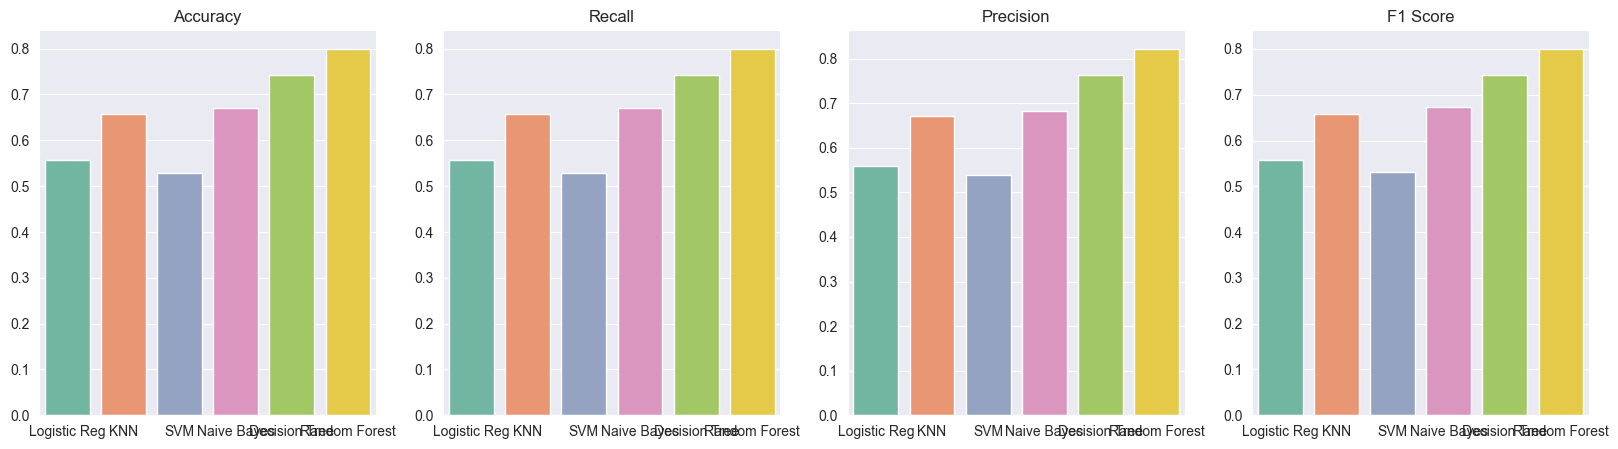

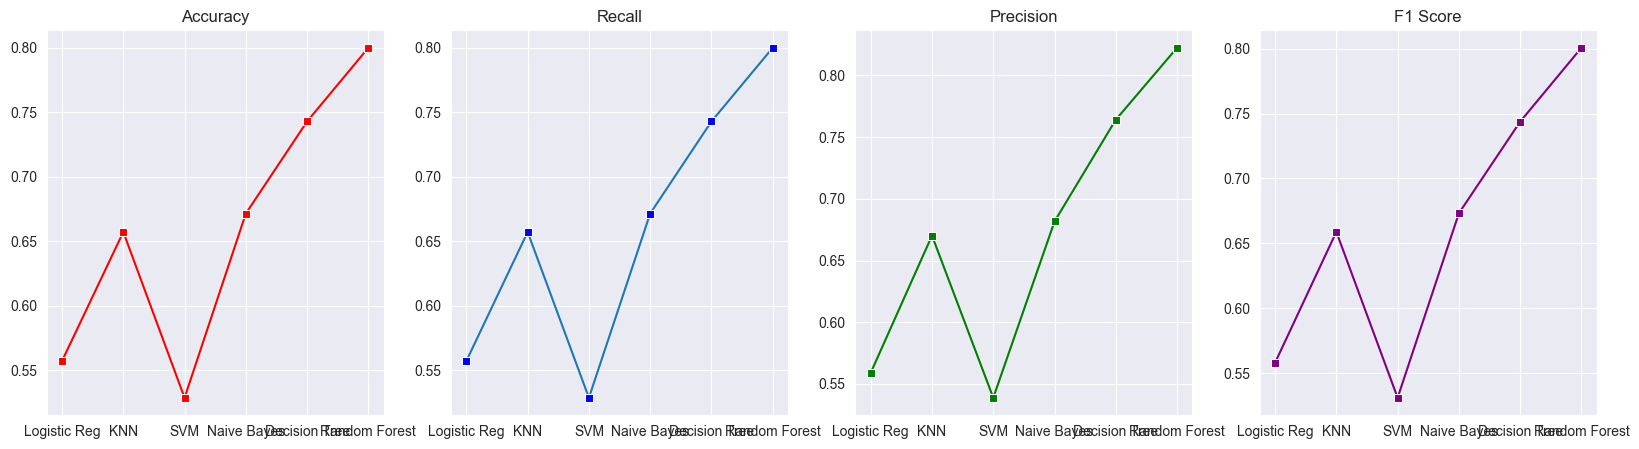

In [125]:
fig, ax = plt.subplots(1, 4, figsize = (20, 5))
sns.set_style('darkgrid')
sns.barplot(x = labels, y = accuracy_list, palette = 'Set2', ax = ax[0]).set_title("Accuracy")
sns.barplot(x = labels, y = recall_list, palette = 'Set2', ax = ax[1]).set_title("Recall")
sns.barplot(x = labels, y = precision_list, palette = 'Set2', ax = ax[2]).set_title("Precision")
sns.barplot(x = labels, y = f1_score_list, palette = 'Set2', ax = ax[3]).set_title("F1 Score")

fig, ax = plt.subplots(1, 4, figsize=(20, 5))
sns.set_style('darkgrid')
sns.lineplot(x = labels, y = accuracy_list, palette = 'Set2', ax = ax[0], marker = 's', color = 'red').set_title("Accuracy")
sns.lineplot(x = labels, y = recall_list, palette = 'Set2', ax = ax[1], marker = 's', markerfacecolor = 'blue').set_title("Recall")
sns.lineplot(x = labels, y = precision_list, palette = 'Set2', ax = ax[2], marker = 's', color = 'green').set_title("Precision")
sns.lineplot(x = labels, y = f1_score_list, palette = 'Set2', ax = ax[3], marker = 's', color = 'purple').set_title("F1 Score")

### **So!! Random Forest is the Best Model as per the subplot.**

## **Make Predictions on New Data**
### The Data that `You` will have to enter to predict `whether you are suffering from any Disease` or not !!

In [126]:
df.head(2)

,Disease,Fever,Cough,Fatigue,Difficulty Breathing,Age,Blood Pressure,Cholesterol Level,Outcome Variable,Gender_Female,Gender_Male
0,1,1.0,0.0,1.0,1.0,19,1,0.0,1.0,1.0,0.0
1,1,0.0,1.0,1.0,0.0,25,0,0.0,0.0,1.0,0.0


In [127]:
new_dataframe = pd.DataFrame({
    'Disease': [1],
    'Fever': [0],
    'Cough': [1],
    'Fatigue': [1],
    'Difficulty Breathing': [0],
    'Age': [29],
    'Blood Pressure': [0],
    'Cholesterol Level': [0],
    'Gender_Female': [1],
    'Gender_Male': [0]
})

In [128]:
# Scale new data
new_data_scaled = scaler.transform(new_dataframe)
prediction = rf_model.predict(new_data_scaled)

In [129]:
print("You have NO disease. The prediction result is Negetive." if prediction == 0 
      else "The prediction result is positive. Yor are suffering from that disease.")

You have NO disease. The prediction result is Negetive.


In [130]:
df.shape

(349, 11)

In [132]:
X_test.shape

(70, 10)

# **Summary**

We downloaded, explored, performed EDA(Exploratory Data Analysis), observed for any missing values and trained few models to search the best model out of it and used that perticular model/algorithm for Credit Score Prediction.

- Total Dataset contains 349 rows and 10 columns.
- After Data processing it has 349 rows and 11 columns.
- Normalized the entire Data.
- Then split the data into train data and test data.
- Training data had approximately 279 rows and 13 columns.
- Test data had approximately 70 rows and 13 columns.
- Trained the model to perform the required Application of predicting the presence of Disease correctly.
- Trained four models:
`LogisticRegression`,`KNNClassifier`, `SVM`, `Naive Bayes`, `DecisionTree` and `RandomForest`.
Among these performance of `RandomForest` was best as it gave the accuracy of 80% on the dataset.

### **Now you can also predict the presence of Disease just by providing few necessary Informations. 😊**

## **THANK YOU 😊**